In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ======================================
# 03_baselines_TFIDF_ML.ipynb
# ======================================

# 1. Imports
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 2. Load Data

PREPROCESSED_TRAIN_CSV = "/content/drive/MyDrive/440proj/uptaded_train_preprocessed.csv"
PREPROCESSED_TEST_CSV = "/content/drive/MyDrive/440proj/uptaded_test_preprocessed.csv"
train_df = pd.read_csv(PREPROCESSED_TRAIN_CSV)
test_df = pd.read_csv(PREPROCESSED_TEST_CSV)

# print(train_df.shape, test_df.shape)
# train_df.head()

# Use clean_text_classical for BoW/TF-IDF
X_train_texts = train_df["clean_text_classical"].values
y_train = train_df["Class"].values

X_test_texts = test_df["clean_text_classical"].values
y_test = test_df["Class"].values

print("Train size:", len(X_train_texts))
print("Test size:", len(X_test_texts))

# 3. Utility Functions
def evaluate_preds(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    print(f"{model_name} — Accuracy: {acc:.4f}, F1: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} — Confusion Matrix")
    plt.show()
    return acc, f1

# Store results
results = []


Train size: 280003
Test size: 59999


In [6]:
# Features and labels
X_train_texts = train_df["clean_text_classical"].fillna("").astype(str)
X_test_texts  = test_df["clean_text_classical"].fillna("").astype(str)

y_train = train_df["Class"]
y_test  = test_df["Class"]

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)


In [7]:
# BoW
# --- CHANGE IS HERE ---
bow_vectorizer = CountVectorizer(max_features=1000, ngram_range=(1,2))
X_train_bow = bow_vectorizer.fit_transform(X_train_texts)
X_test_bow  = bow_vectorizer.transform(X_test_texts)

# TF-IDF
# --- AND HERE ---
tfidf_vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1,2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_texts)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_texts)

print("BoW shape:", X_train_bow.shape, "TF-IDF shape:", X_train_tfidf.shape)

BoW shape: (280003, 1000) TF-IDF shape: (280003, 1000)


In [11]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [12]:
num_classes = len(label_encoder.classes_)
y_train_ohe = to_categorical(y_train_enc, num_classes=num_classes)
y_test_ohe = to_categorical(y_test_enc, num_classes=num_classes)

print("Shape of one-hot encoded training labels:", y_train_ohe.shape)
print("Shape of one-hot encoded testing labels:", y_test_ohe.shape)

Shape of one-hot encoded training labels: (280003, 10)
Shape of one-hot encoded testing labels: (59999, 10)


In [13]:
def build_dnn_model(input_shape, num_classes):
    """Builds a simple feed-forward deep neural network."""
    model = Sequential([
        Dense(256, activation="relu", input_shape=input_shape),
        Dropout(0.5),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax") # Softmax for multi-class classification
    ])

    optimizer = Adam(learning_rate=0.001)
    model.compile(
        loss="categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )
    return model

def evaluate_model_dnn(model, model_name, X_test, y_test_ohe, class_names):
    """Evaluates the trained Keras DNN model."""
    # Get predictions (probabilities)
    y_pred_probs = model.predict(X_test)
    # Convert probabilities to class labels
    y_pred = np.argmax(y_pred_probs, axis=1)

    y_true = np.argmax(y_test_ohe, axis=1)

    evaluate_preds(model_name, y_true, y_pred)

In [14]:
# --- DNN + BoW ---
print("==== Training DNN with Bag of Words ====")
dnn_bow_model = build_dnn_model(input_shape=(X_train_bow.shape[1],), num_classes=num_classes)
dnn_bow_model.summary()

history_bow = dnn_bow_model.fit(
    X_train_bow.toarray(), y_train_ohe,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

==== Training DNN with Bag of Words ====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       256,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,442 (1.11 MB)

 Trainable params: 290,442 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.4750 - loss: 1.6224 - val_accuracy: 0.6092 - val_loss: 1.2279
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.5928 - loss: 1.2867 - val_accuracy: 0.6142 - val_loss: 1.1972
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.6081 - loss: 1.2330 - val_accuracy: 0.6159 - val_loss: 1.1849
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.6130 - loss: 1.2040 - val_accuracy: 0.6168 - val_loss: 1.1792
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.6173 - loss: 1.1864 - val_accuracy: 0.6193 - val_loss: 1.1759
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.6223 - loss: 1.1685 - val_accuracy: 0.6197 - val_loss: 1.1741
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.6268 - loss: 1.1529 - val_accuracy: 0.6193 - val_loss: 1.1750
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.6301 -

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
DNN (BoW) — Accuracy: 0.6182, F1: 0.6122

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.40      0.48      6000
           1       0.71      0.80      0.76      6000
           2       0.51      0.40      0.45      6000
           3       0.52      0.60      0.56      6000
           4       0.61      0.75      0.67      5999
           5       0.67      0.70      0.68      6000
           6       0.69      0.65      0.67      6000
           7       0.54      0.71      0.61      6000
           8       0.59      0.46      0.52      6000
           9       0.74      0.71      0.72      6000

    accuracy                           0.62     59999
   macro avg       0.62      0.62      0.61     59999
weighted avg       0.62      0.62      0.61     59999



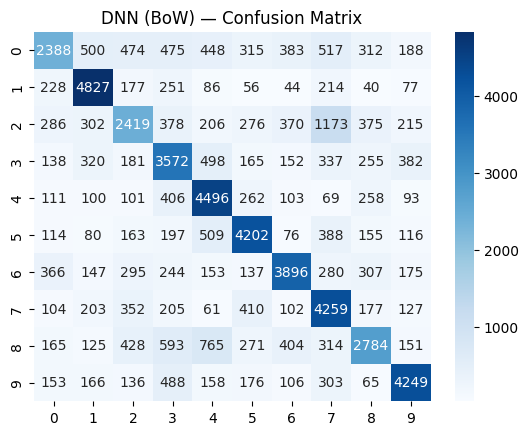

In [16]:
evaluate_model_dnn(dnn_bow_model, "DNN (BoW)", X_test_bow, y_test_ohe, label_encoder.classes_)

\n==== Training DNN with TF-IDF ====


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       256,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,442 (1.11 MB)

 Trainable params: 290,442 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.4925 - loss: 1.5518 - val_accuracy: 0.6138 - val_loss: 1.1988
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - accuracy: 0.6021 - loss: 1.2494 - val_accuracy: 0.6158 - val_loss: 1.1821
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.6125 - loss: 1.2115 - val_accuracy: 0.6181 - val_loss: 1.1732
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.6185 - loss: 1.1879 - val_accuracy: 0.6193 - val_loss: 1.1687
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 56s 19ms/step - accuracy: 0.6222 - loss: 1.1740 - val_accuracy: 0.6208 - val_loss: 1.1633
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.6292 - loss: 1.1557 - val_accuracy: 0.6203 - val_loss: 1.1620
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.6310 - loss: 1.1421 - val_accuracy: 0.6234 - val_loss: 1.1581
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.6355 -

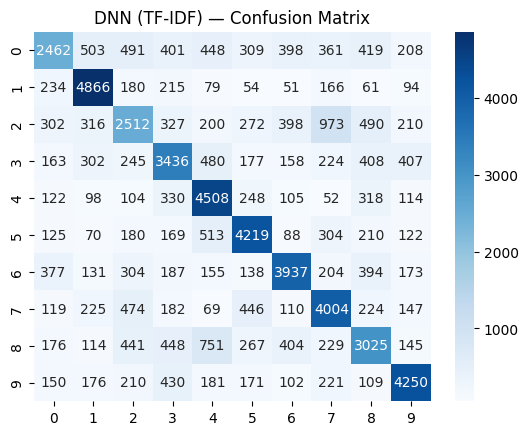

In [15]:
# --- DNN + TF-IDF ---
print("\\n==== Training DNN with TF-IDF ====")
dnn_tfidf_model = build_dnn_model(input_shape=(X_train_tfidf.shape[1],), num_classes=num_classes)
dnn_tfidf_model.summary()

history_tfidf = dnn_tfidf_model.fit(
    X_train_tfidf, y_train_ohe,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

evaluate_model_dnn(dnn_tfidf_model, "DNN (TF-IDF)", X_test_bow, y_test_ohe, label_encoder.classes_)